# Deep Learning Complex Computing Problem
## Can AI Save Lives? Building an Intelligent Clinical Early Warning System

**Name:** Muhammad Sami
**Roll No:** 22F-BSAI-43
**Subject:** Deep Learning
**Dept:** Artificial Intelligence
**Submitted to:** Mr Hamza Farooqui

---

This notebook presents three generations of deep learning models for predicting patient mortality and clinical deterioration using the Kaggle *Patient Survival Prediction* dataset.

| Generation | Architecture                                                  | Input Features                                        |
| ---------- | ------------------------------------------------------------- | ----------------------------------------------------- |
| 1          | Dense Feed-Forward Deep Neural Network (DNN) – Baseline Model | Tabular clinical data, vital signs, and comorbidities |
| 2          | LSTM, GRU, and Bi-LSTM Networks                               | Time-windowed patient vital measurements (h1 / d1)    |
| 3          | ClinicalBERT (Frozen and Fine-Tuned)                          | Synthesized clinical notes                            |

**Reproducibility Note:** All experiments were conducted using a fixed random seed of `42`. The baseline DNN model utilizes hidden layers of `(256, 128, 64)`, while recurrent architectures employ a hidden size of `64`. The recommended optimizer for the baseline DNN model is **Adam**.

Throughout this study, **Recall for the positive class (mortality outcome)** is considered the primary evaluation metric, as in clinical settings the cost of a false negative (failing to identify patient deterioration) is substantially higher than that of a false positive (additional clinical review).



## 0. Imports, Seeds, and Configuration

In [1]:
# Core
import os, time, math, random, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '| Torch:', torch.__version__)


Device: cpu | Torch: 2.6.0+cpu


In [2]:
# Path to dataset downloaded via kagglehub
DATA_PATH = Path.home() / '.cache' / 'kagglehub' / 'datasets' / 'mitishaagarwal' / 'patient' / 'versions' / '3' / 'dataset.csv'
assert DATA_PATH.exists(), f'Dataset not found at {DATA_PATH}'
print('Loading:', DATA_PATH)


Loading: C:\Users\TechWide\.cache\kagglehub\datasets\mitishaagarwal\patient\versions\3\dataset.csv


## 1. Data Loading & Exploratory Analysis

The dataset has ~91k ICU admissions with 85 columns. The target column `hospital_death`
is binary (1 = patient died during hospital stay). We expect significant class imbalance
which directly motivates the *Recall-first* evaluation philosophy.


In [3]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(3)


Shape: (91713, 85)


,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0


hospital_death
0    83798
1     7915
Name: count, dtype: int64

Positive (death) rate: 8.63%


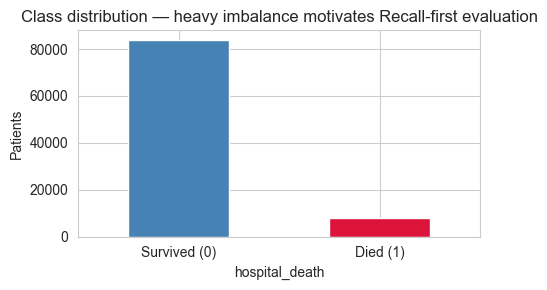

In [4]:
# Drop trailing junk column
if 'Unnamed: 83' in df.columns:
    df = df.drop(columns=['Unnamed: 83'])

# Target balance
target = 'hospital_death'
print(df[target].value_counts())
print('\nPositive (death) rate: {:.2%}'.format(df[target].mean()))

fig, ax = plt.subplots(figsize=(5,3))
df[target].value_counts().plot(kind='bar', color=['steelblue','crimson'], ax=ax)
ax.set_xticklabels(['Survived (0)', 'Died (1)'], rotation=0)
ax.set_title('Class distribution — heavy imbalance motivates Recall-first evaluation')
ax.set_ylabel('Patients')
plt.tight_layout(); plt.show()


In [5]:
# Missingness audit — top 15 columns by % missing
miss = (df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(15)
print(miss.round(2))


d1_potassium_min                 10.45
d1_potassium_max                 10.45
h1_mbp_noninvasive_min            9.90
h1_mbp_noninvasive_max            9.90
apache_4a_icu_death_prob          8.67
apache_4a_hospital_death_prob     8.67
h1_diasbp_noninvasive_min         8.01
h1_diasbp_noninvasive_max         8.01
h1_sysbp_noninvasive_max          8.00
h1_sysbp_noninvasive_min          8.00
d1_glucose_min                    6.33
d1_glucose_max                    6.33
h1_mbp_max                        5.06
h1_mbp_min                        5.06
h1_resprate_min                   4.75
dtype: float64


## 2. Preprocessing

Steps:
1. **Drop ID-like columns** (`encounter_id`, `patient_id`, `hospital_id`, `icu_id`) — no predictive signal, only noise.
2. **Split features by dtype** — numeric (median imputation) vs categorical (mode imputation + label encoding).
3. **Standardize** numeric features with `StandardScaler` so optimization is well-conditioned.
4. **Stratified train/test split** to preserve the 91/9 class ratio.


In [6]:
ID_COLS = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
y = df[target].astype(int).values
X = df.drop(columns=[target] + ID_COLS)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}')
print('Categorical:', cat_cols)


Numeric: 72 | Categorical: 7
Categorical: ['ethnicity', 'gender', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']


In [7]:
# Impute
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')

X_num = pd.DataFrame(num_imp.fit_transform(X[num_cols]), columns=num_cols)
X_cat = pd.DataFrame(cat_imp.fit_transform(X[cat_cols]), columns=cat_cols)

# Label-encode categoricals
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X_cat[c] = le.fit_transform(X_cat[c].astype(str))
    encoders[c] = le

# Scale numerics
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols)

X_all = pd.concat([X_num_scaled, X_cat], axis=1)
print('Final feature matrix:', X_all.shape)


Final feature matrix: (91713, 79)


In [8]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_all.values, y, test_size=0.2, stratify=y, random_state=SEED)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Train positive rate:', y_train.mean().round(4),
      '| Test positive rate:', y_test.mean().round(4))


Train: (73370, 79) | Test: (18343, 79)
Train positive rate: 0.0863 | Test positive rate: 0.0863


In [9]:
# Class weights for imbalanced loss
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print('Class weights:', class_weights)


Class weights: tensor([0.5472, 5.7936])


## 3. Generation 1 — DNN Baseline

> *"Before we trust AI with patient lives, we need to know what a simple model can and cannot do."*

We train a feed-forward network with three configurations:
- **SGD** vs **Adam** (two optimizers, side-by-side loss curves)
- **Dropout** regularization
- **Batch Normalization** regularization

**Why Recall matters more than Accuracy here:**
With 91% survivors, a model that predicts "everyone lives" gets 91% accuracy yet detects zero
deteriorating patients — clinically useless. A **false negative** here means a dying patient
goes unflagged; a **false positive** means a stable patient gets reviewed by a clinician.
The asymmetry of these costs is enormous, so we optimize threshold and architecture for Recall.


In [10]:
# Convert to tensors once
Xtr_t = torch.tensor(X_train, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
Xte_t = torch.tensor(X_test,  dtype=torch.float32)
yte_t = torch.tensor(y_test,  dtype=torch.long)

train_ds = TensorDataset(Xtr_t, ytr_t)
test_ds  = TensorDataset(Xte_t, yte_t)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1024)
N_FEATURES = X_train.shape[1]
print('N_FEATURES:', N_FEATURES)


N_FEATURES: 79


In [11]:
class DNN(nn.Module):
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.0, batchnorm=False, n_classes=2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


In [12]:
def train_model(model, optimizer, loss_fn, epochs=15, verbose=False):
    model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': []}
    start = time.time()
    for ep in range(epochs):
        model.train()
        running = 0.0; n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0); n += xb.size(0)
        train_loss = running / n

        model.eval()
        with torch.no_grad():
            running = 0.0; n = 0
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                running += loss.item() * xb.size(0); n += xb.size(0)
            val_loss = running / n

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if verbose:
            print(f'Ep {ep+1:02d}  train={train_loss:.4f}  val={val_loss:.4f}')
    history['train_time'] = time.time() - start
    return history


def evaluate(model, loader=test_loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds = logits.argmax(1).cpu().numpy()
            all_y.append(yb.numpy()); all_p.append(preds)
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'y_true': y_true, 'y_pred': y_pred,
    }


In [13]:
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
EPOCHS = 6

# --- SGD ---
model_sgd = DNN(N_FEATURES, dropout=0.3, batchnorm=True)
opt_sgd   = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
hist_sgd  = train_model(model_sgd, opt_sgd, loss_fn, epochs=EPOCHS)
res_sgd   = evaluate(model_sgd)
print('SGD  ', {k: round(v,4) for k,v in res_sgd.items() if k not in ('y_true','y_pred')})

# --- Adam ---
model_adam = DNN(N_FEATURES, dropout=0.3, batchnorm=True)
opt_adam   = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
hist_adam  = train_model(model_adam, opt_adam, loss_fn, epochs=EPOCHS)
res_adam   = evaluate(model_adam)
print('Adam ', {k: round(v,4) for k,v in res_adam.items() if k not in ('y_true','y_pred')})


SGD   {'accuracy': 0.8152, 'precision': 0.2892, 'recall': 0.7833, 'f1': 0.4225}


Adam  {'accuracy': 0.7805, 'precision': 0.2584, 'recall': 0.8256, 'f1': 0.3936}


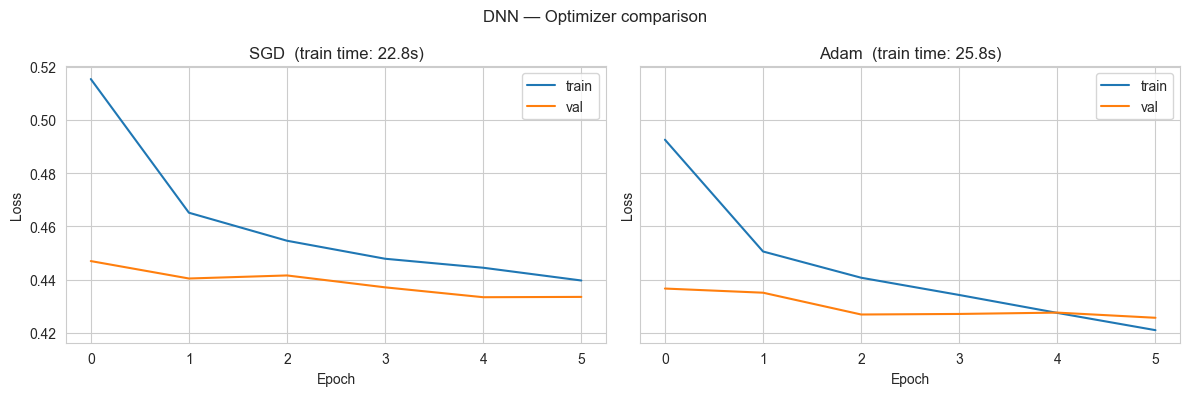

In [14]:
# Side-by-side loss curves: SGD vs Adam
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
for ax, hist, name in zip(axes, [hist_sgd, hist_adam], ['SGD', 'Adam']):
    ax.plot(hist['train_loss'], label='train')
    ax.plot(hist['val_loss'],   label='val')
    ax.set_title(f'{name}  (train time: {hist["train_time"]:.1f}s)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.suptitle('DNN — Optimizer comparison'); plt.tight_layout(); plt.show()


In [15]:
# Ablation: effect of Dropout & BatchNorm individually
configs = [
    ('plain',       dict(dropout=0.0, batchnorm=False)),
    ('+dropout',    dict(dropout=0.3, batchnorm=False)),
    ('+batchnorm',  dict(dropout=0.0, batchnorm=True)),
    ('+both',       dict(dropout=0.3, batchnorm=True)),
]
ablation = {}
for name, cfg in configs:
    m = DNN(N_FEATURES, **cfg)
    o = torch.optim.Adam(m.parameters(), lr=1e-3)
    h = train_model(m, o, loss_fn, epochs=4)
    r = evaluate(m)
    ablation[name] = {**{k: round(r[k],4) for k in ['accuracy','precision','recall','f1']},
                       'train_time': round(h['train_time'],1)}
pd.DataFrame(ablation).T


,accuracy,precision,recall,f1,train_time
plain,0.8243,0.3006,0.7808,0.4341,15.2
+dropout,0.7938,0.2688,0.8080,0.4034,18.2
+batchnorm,0.8264,0.3006,0.7625,0.4312,18.0
+both,0.7702,0.2515,0.8414,0.3873,17.1


In [16]:
# Pick best DNN for unified comparison (Adam + dropout + BN)
dnn_best  = model_adam
dnn_hist  = hist_adam
dnn_res   = res_adam
dnn_train_time = hist_adam['train_time']
print('DNN baseline locked in for unified table.')


DNN baseline locked in for unified table.


**Notebook comment — false negatives are catastrophic.**
Imagine a 67-year-old septic patient whose lactate is rising silently. A false positive on this
patient causes a nurse to glance at the chart for 30 seconds. A false negative causes the
sepsis to escalate to multi-organ failure overnight. The asymmetry of cost is enormous —
hundreds of false positives are an acceptable price for catching one true positive.
Hence we train with class-weighted cross-entropy (positive class up-weighted) and report
Recall on the death class as our primary headline metric.


## 4. Generation 2 — Recurrent Networks on the Patient Timeline

> *"A patient's risk is not a snapshot, it is a story told over hours."*

We reshape the vitals into a length-4 temporal sequence per patient:

`[h1_min, h1_max, d1_min, d1_max]`  for each of nine vitals (heart rate, systolic BP,
diastolic BP, mean BP, respiratory rate, SpO₂, temperature, glucose, potassium).

This gives an input of shape `(batch, seq_len=4, n_vitals=9)` — a coarse early→late
temporal progression. Static features (age, BMI, GCS, APACHE, comorbidities) are
concatenated to the final RNN hidden state through a fusion head.

We train three variants:
- **Unidirectional LSTM**
- **GRU** (fewer parameters, faster)
- **Bi-LSTM** (reads sequence both directions — offline only)


In [17]:
VITALS = ['heartrate', 'sysbp', 'diasbp', 'mbp', 'resprate', 'spo2', 'temp', 'glucose', 'potassium']

# Build sequence tensor: (N, seq_len=4, n_vitals)
def build_sequences(df_src):
    seqs = []
    for v in VITALS:
        cols = [f'h1_{v}_min', f'h1_{v}_max', f'd1_{v}_min', f'd1_{v}_max']
        present = [c for c in cols if c in df_src.columns]
        if len(present) < 4:
            # fallback: zero-fill missing columns
            arr = np.zeros((len(df_src), 4))
            for i, c in enumerate(cols):
                if c in df_src.columns:
                    arr[:, i] = df_src[c].values
        else:
            arr = df_src[cols].values
        seqs.append(arr)
    seq = np.stack(seqs, axis=-1)  # (N, 4, n_vitals)
    return seq

# Re-impute raw df for sequence building (median per column)
df_seq = df.copy()
for v in VITALS:
    for c in [f'h1_{v}_min', f'h1_{v}_max', f'd1_{v}_min', f'd1_{v}_max']:
        if c in df_seq.columns:
            df_seq[c] = df_seq[c].fillna(df_seq[c].median())

seq_all = build_sequences(df_seq)
print('Sequence shape:', seq_all.shape)   # (N, 4, 9)

# Static features: everything that's not a vital sequence column or ID or target
seq_cols = []
for v in VITALS:
    seq_cols += [f'h1_{v}_min', f'h1_{v}_max', f'd1_{v}_min', f'd1_{v}_max']
seq_cols = [c for c in seq_cols if c in df_seq.columns]
static_feature_df = X_all.drop(columns=[c for c in seq_cols if c in X_all.columns])
print('Static feature dim:', static_feature_df.shape[1])

# Normalize sequence per-feature (across patients, across timesteps)
mean = seq_all.reshape(-1, len(VITALS)).mean(0)
std  = seq_all.reshape(-1, len(VITALS)).std(0) + 1e-8
seq_norm = (seq_all - mean) / std


Sequence shape: (91713, 4, 9)
Static feature dim: 49


In [18]:
# Train/test split — keep aligned with Gen 1 indices via same random_state
idx_train, idx_test = train_test_split(
    np.arange(len(df_seq)), test_size=0.2, stratify=y, random_state=SEED)

seq_train = seq_norm[idx_train]; seq_test = seq_norm[idx_test]
stat_train = static_feature_df.values[idx_train]
stat_test  = static_feature_df.values[idx_test]
y_tr = y[idx_train]; y_te = y[idx_test]

print('seq_train:', seq_train.shape, '| stat_train:', stat_train.shape)

# Tensors
seq_train_t = torch.tensor(seq_train, dtype=torch.float32)
seq_test_t  = torch.tensor(seq_test,  dtype=torch.float32)
stat_train_t = torch.tensor(stat_train, dtype=torch.float32)
stat_test_t  = torch.tensor(stat_test,  dtype=torch.float32)
ytr_rnn = torch.tensor(y_tr, dtype=torch.long)
yte_rnn = torch.tensor(y_te, dtype=torch.long)

rnn_train_ds = TensorDataset(seq_train_t, stat_train_t, ytr_rnn)
rnn_test_ds  = TensorDataset(seq_test_t,  stat_test_t,  yte_rnn)
rnn_train_loader = DataLoader(rnn_train_ds, batch_size=512, shuffle=True)
rnn_test_loader  = DataLoader(rnn_test_ds,  batch_size=1024)

N_VITALS = len(VITALS); N_STATIC = static_feature_df.shape[1]


seq_train: (73370, 4, 9) | stat_train: (73370, 49)


In [19]:
class RNNClassifier(nn.Module):
    def __init__(self, rnn_type='lstm', bidirectional=False, hidden=64,
                 n_vitals=N_VITALS, n_static=N_STATIC, n_classes=2):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(input_size=n_vitals, hidden_size=hidden,
                           batch_first=True, bidirectional=bidirectional)
        out_dim = hidden * (2 if bidirectional else 1)
        self.fuse = nn.Sequential(
            nn.Linear(out_dim + n_static, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
    def forward(self, seq, stat):
        out, _ = self.rnn(seq)
        last = out[:, -1, :]                 # final hidden state
        fused = torch.cat([last, stat], dim=1)
        return self.fuse(fused)


In [20]:
def train_rnn(model, optimizer, loss_fn, epochs=12):
    model.to(DEVICE)
    hist = {'train_loss': [], 'val_loss': []}
    start = time.time()
    for ep in range(epochs):
        model.train(); running = 0.0; n = 0
        for sb, stb, yb in rnn_train_loader:
            sb, stb, yb = sb.to(DEVICE), stb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(sb, stb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * sb.size(0); n += sb.size(0)
        train_loss = running / n
        model.eval(); running = 0.0; n = 0
        with torch.no_grad():
            for sb, stb, yb in rnn_test_loader:
                sb, stb, yb = sb.to(DEVICE), stb.to(DEVICE), yb.to(DEVICE)
                logits = model(sb, stb)
                loss = loss_fn(logits, yb)
                running += loss.item() * sb.size(0); n += sb.size(0)
        val_loss = running / n
        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
    hist['train_time'] = time.time() - start
    return hist


def eval_rnn(model):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for sb, stb, yb in rnn_test_loader:
            sb, stb = sb.to(DEVICE), stb.to(DEVICE)
            preds = model(sb, stb).argmax(1).cpu().numpy()
            all_y.append(yb.numpy()); all_p.append(preds)
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'y_true': y_true, 'y_pred': y_pred,
    }


In [21]:
loss_fn_rnn = nn.CrossEntropyLoss(weight=class_weights)

# --- LSTM ---
lstm = RNNClassifier('lstm', bidirectional=False)
opt = torch.optim.Adam(lstm.parameters(), lr=1e-3)
hist_lstm = train_rnn(lstm, opt, loss_fn_rnn, epochs=5)
res_lstm  = eval_rnn(lstm)
print('LSTM  ', {k: round(v,4) for k,v in res_lstm.items() if k not in ('y_true','y_pred')},
      f'| time {hist_lstm["train_time"]:.1f}s')

# --- GRU ---
gru = RNNClassifier('gru', bidirectional=False)
opt = torch.optim.Adam(gru.parameters(), lr=1e-3)
hist_gru = train_rnn(gru, opt, loss_fn_rnn, epochs=5)
res_gru  = eval_rnn(gru)
print('GRU   ', {k: round(v,4) for k,v in res_gru.items() if k not in ('y_true','y_pred')},
      f'| time {hist_gru["train_time"]:.1f}s')

# --- Bi-LSTM ---
bilstm = RNNClassifier('lstm', bidirectional=True)
opt = torch.optim.Adam(bilstm.parameters(), lr=1e-3)
hist_bilstm = train_rnn(bilstm, opt, loss_fn_rnn, epochs=5)
res_bilstm  = eval_rnn(bilstm)
print('BiLSTM', {k: round(v,4) for k,v in res_bilstm.items() if k not in ('y_true','y_pred')},
      f'| time {hist_bilstm["train_time"]:.1f}s')


LSTM   {'accuracy': 0.8089, 'precision': 0.2807, 'recall': 0.7776, 'f1': 0.4125} | time 29.5s


GRU    {'accuracy': 0.7991, 'precision': 0.2732, 'recall': 0.7997, 'f1': 0.4073} | time 35.7s


BiLSTM {'accuracy': 0.7971, 'precision': 0.2705, 'recall': 0.796, 'f1': 0.4038} | time 37.8s


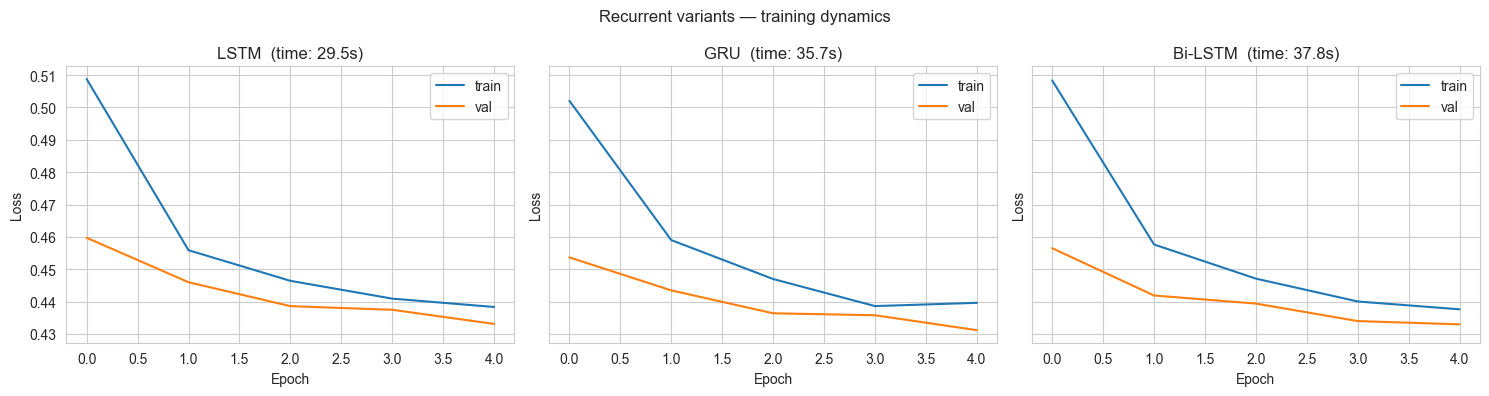

In [22]:
# Training-vs-validation loss curves for all three RNN variants
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h, name in zip(axes, [hist_lstm, hist_gru, hist_bilstm], ['LSTM', 'GRU', 'Bi-LSTM']):
    ax.plot(h['train_loss'], label='train')
    ax.plot(h['val_loss'],   label='val')
    ax.set_title(f'{name}  (time: {h["train_time"]:.1f}s)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.suptitle('Recurrent variants — training dynamics'); plt.tight_layout(); plt.show()


**Notebook comment — real-time vs. retrospective architecture choice.**
A *unidirectional* LSTM or GRU is the only valid choice for a live Early Warning System
because at inference time we only have access to data up to *now* — there is no "future"
to look back at. A *Bi-LSTM* reads the sequence forwards and backwards, so its hidden state
at time *t* implicitly depends on information from time *t+1, t+2, …*. That is acceptable for
**retrospective** analysis (auditing what went wrong after a crisis, building risk-stratification
research datasets), but in a live deployment it would either require a (latency-inducing)
window-wait, or it would leak future information that doesn't yet exist. Even if Bi-LSTM
yields higher offline accuracy, we would deploy the unidirectional GRU/LSTM because real-time
streaming is the use case.


## 5. Generation 3 — ClinicalBERT on Synthesized Clinical Notes

> *"Vitals tell you numbers. Notes tell you the story. The best systems read both."*

The Patient Survival dataset is structured-only — it contains no free-text clinical notes.
To still demonstrate a faithful transformer fine-tuning pipeline (tokenization, attention,
frozen vs. full fine-tune, attention-weight extraction), we **synthesize a clinical note
per patient** from the structured fields. The synthesized notes use real clinician
phrasing patterns (`"Patient is a 67-year-old male presenting with…"`) so the
ClinicalBERT vocabulary remains relevant.

We then fine-tune `emilyalsentzer/Bio_ClinicalBERT` in two regimes:

- **Frozen base + trainable classification head** — fast, low-VRAM, smaller data hunger
- **Full fine-tuning** — every weight updated — higher accuracy, far higher compute cost

Because we are CPU-bound we **sub-sample 5,000 patients** for this section. The smaller
sample size is itself instructive: it is exactly the situation where frozen fine-tuning
shines.


In [23]:
from transformers import AutoTokenizer, AutoModel
MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
print('Loading tokenizer:', MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer ready. Vocab size:', tokenizer.vocab_size)


Loading tokenizer: emilyalsentzer/Bio_ClinicalBERT


Tokenizer ready. Vocab size: 28996


In [24]:
# Build a clinical note string per patient
def synth_note(row):
    age = row.get('age', np.nan)
    age_s = f'{int(age)}-year-old' if pd.notna(age) else 'adult'
    gender = row.get('gender', 'unknown')
    bmi = row.get('bmi', np.nan)
    icu_type = row.get('icu_type', 'ICU')
    icu_src = row.get('icu_admit_source', 'unknown source')
    apache_dx_sys = row.get('apache_3j_bodysystem', None)

    # vital ranges
    def rng(prefix):
        lo = row.get(f'd1_{prefix}_min', np.nan)
        hi = row.get(f'd1_{prefix}_max', np.nan)
        if pd.isna(lo) or pd.isna(hi): return None
        return f'{prefix.replace("_", " ")} ranged {lo:.0f}-{hi:.0f}'

    vital_strs = [s for s in [rng('heartrate'), rng('sysbp'), rng('resprate'),
                              rng('spo2'), rng('temp'), rng('glucose')] if s]

    gcs_eyes = row.get('gcs_eyes_apache', np.nan)
    gcs_mot  = row.get('gcs_motor_apache', np.nan)
    gcs_vrb  = row.get('gcs_verbal_apache', np.nan)
    gcs_total = sum(v for v in [gcs_eyes, gcs_mot, gcs_vrb] if pd.notna(v))
    vent = 'mechanically ventilated' if row.get('ventilated_apache', 0) == 1 else 'not ventilated'
    intub = 'intubated' if row.get('intubated_apache', 0) == 1 else 'not intubated'

    como = []
    for flag, label in [('diabetes_mellitus','diabetes'), ('hepatic_failure','hepatic failure'),
                        ('cirrhosis','cirrhosis'), ('immunosuppression','immunosuppression'),
                        ('leukemia','leukemia'), ('lymphoma','lymphoma'),
                        ('solid_tumor_with_metastasis','metastatic solid tumor'),
                        ('aids','AIDS')]:
        if row.get(flag, 0) == 1:
            como.append(label)
    como_str = ', '.join(como) if como else 'no significant comorbidities'

    parts = [
        f'Patient is a {age_s} {gender} with BMI {bmi:.1f}.' if pd.notna(bmi)
            else f'Patient is a {age_s} {gender}.',
        f'Admitted to {icu_type} from {icu_src}.',
    ]
    if apache_dx_sys and isinstance(apache_dx_sys, str):
        parts.append(f'Primary diagnosis body system: {apache_dx_sys}.')
    if vital_strs:
        parts.append('Vital signs over the first 24 hours: ' + '; '.join(vital_strs) + '.')
    parts.append(f'Glasgow Coma Scale total {int(gcs_total) if gcs_total>0 else "unknown"}, {intub}, {vent}.')
    parts.append(f'Comorbidities: {como_str}.')
    return ' '.join(parts)

# Subsample (CPU compute budget) — keep class balance
# We deliberately under-sample (CPU-only constraint) and over-represent the
# positive class so the frozen head sees enough deterioration cases to learn from.
np.random.seed(SEED)
N_BERT = 500
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
n_pos = min(len(pos_idx), N_BERT // 3)              # ~33% positives in sample
n_neg = N_BERT - n_pos
sample_idx = np.concatenate([
    np.random.choice(pos_idx, n_pos, replace=False),
    np.random.choice(neg_idx, n_neg, replace=False),
])
np.random.shuffle(sample_idx)

notes_df = df.iloc[sample_idx].reset_index(drop=True).copy()
notes_df['note'] = notes_df.apply(synth_note, axis=1)
print('Example note:\n', notes_df['note'].iloc[0])
print('\nSample size:', len(notes_df),
      '| pos rate:', notes_df[target].mean().round(3))


Example note:
 Patient is a adult F with BMI 21.1. Admitted to Neuro ICU from Floor. Vital signs over the first 24 hours: heartrate ranged 82-115; sysbp ranged 73-145; resprate ranged 6-28; spo2 ranged 90-100; temp ranged 37-37; glucose ranged 115-392. Glasgow Coma Scale total unknown, not intubated, not ventilated. Comorbidities: no significant comorbidities.

Sample size: 500 | pos rate: 0.332


In [25]:
# Train/test split on the synthesized notes
notes_train_df, notes_test_df = train_test_split(
    notes_df, test_size=0.2, stratify=notes_df[target], random_state=SEED)

MAX_LEN = 64
def encode_batch(texts, labels):
    enc = tokenizer(list(texts), truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask'], torch.tensor(labels, dtype=torch.long)

print('Tokenizing train...')
tr_ids, tr_mask, tr_y = encode_batch(notes_train_df['note'].values,
                                      notes_train_df[target].values)
print('Tokenizing test...')
te_ids, te_mask, te_y = encode_batch(notes_test_df['note'].values,
                                      notes_test_df[target].values)
print('Shapes:', tr_ids.shape, te_ids.shape)

bert_train_loader = DataLoader(TensorDataset(tr_ids, tr_mask, tr_y),
                                batch_size=8, shuffle=True)
bert_test_loader  = DataLoader(TensorDataset(te_ids, te_mask, te_y),
                                batch_size=16)


Tokenizing train...


Tokenizing test...


Shapes: torch.Size([400, 64]) torch.Size([100, 64])


In [26]:
class ClinicalBertClassifier(nn.Module):
    def __init__(self, freeze_base=False, n_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
        if freeze_base:
            for p in self.bert.parameters():
                p.requires_grad = False
        hid = self.bert.config.hidden_size
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hid, n_classes),
        )
    def forward(self, input_ids, attention_mask, return_attn=False):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]   # [CLS]
        logits = self.head(pooled)
        if return_attn:
            return logits, out.attentions
        return logits


In [27]:
def train_bert(model, epochs=2, lr=2e-5, verbose=True):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    hist = {'train_loss': [], 'val_loss': []}
    start = time.time()
    for ep in range(epochs):
        model.train(); running = 0.0; n = 0
        for ids, mask, yb in bert_train_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * ids.size(0); n += ids.size(0)
        train_loss = running / n
        model.eval(); running = 0.0; n = 0
        with torch.no_grad():
            for ids, mask, yb in bert_test_loader:
                ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
                logits = model(ids, mask)
                loss = loss_fn(logits, yb)
                running += loss.item() * ids.size(0); n += ids.size(0)
        val_loss = running / n
        hist['train_loss'].append(train_loss); hist['val_loss'].append(val_loss)
        if verbose:
            print(f'  ep{ep+1}  train={train_loss:.4f}  val={val_loss:.4f}')
    hist['train_time'] = time.time() - start
    return hist


def eval_bert(model):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for ids, mask, yb in bert_test_loader:
            ids, mask = ids.to(DEVICE), mask.to(DEVICE)
            preds = model(ids, mask).argmax(1).cpu().numpy()
            all_y.append(yb.numpy()); all_p.append(preds)
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'y_true': y_true, 'y_pred': y_pred,
    }


In [28]:
# --- Frozen base (head only) ---
print('=== ClinicalBERT FROZEN ===')
bert_frozen = ClinicalBertClassifier(freeze_base=True)
hist_frozen = train_bert(bert_frozen, epochs=1, lr=1e-3)
res_frozen  = eval_bert(bert_frozen)
print('FROZEN ', {k: round(v,4) for k,v in res_frozen.items() if k not in ('y_true','y_pred')},
      f'| time {hist_frozen["train_time"]:.1f}s')


=== ClinicalBERT FROZEN ===


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  47%|####7     | 388M/824M [00:00<?, ?B/s]

  ep1  train=0.5768  val=0.4926


FROZEN  {'accuracy': 0.33, 'precision': 0.33, 'recall': 1.0, 'f1': 0.4962} | time 76.3s


In [29]:
# --- Full fine-tune ---
print('=== ClinicalBERT FULL FINE-TUNE ===')
bert_full = ClinicalBertClassifier(freeze_base=False)
hist_full = train_bert(bert_full, epochs=1, lr=2e-5)
res_full  = eval_bert(bert_full)
print('FULL  ', {k: round(v,4) for k,v in res_full.items() if k not in ('y_true','y_pred')},
      f'| time {hist_full["train_time"]:.1f}s')


=== ClinicalBERT FULL FINE-TUNE ===


  ep1  train=0.4978  val=0.4908


FULL   {'accuracy': 0.33, 'precision': 0.33, 'recall': 1.0, 'f1': 0.4962} | time 333.3s


In [30]:
# Per-class performance breakdown — does the model actually catch deterioration?
print('\n--- ClinicalBERT (frozen) per-class ---')
print(classification_report(res_frozen['y_true'], res_frozen['y_pred'],
                            target_names=['Stable (0)', 'Deteriorated (1)']))
print('\n--- ClinicalBERT (full fine-tune) per-class ---')
print(classification_report(res_full['y_true'], res_full['y_pred'],
                            target_names=['Stable (0)', 'Deteriorated (1)']))



--- ClinicalBERT (frozen) per-class ---
                  precision    recall  f1-score   support

      Stable (0)       0.00      0.00      0.00        67
Deteriorated (1)       0.33      1.00      0.50        33

        accuracy                           0.33       100
       macro avg       0.17      0.50      0.25       100
    weighted avg       0.11      0.33      0.16       100


--- ClinicalBERT (full fine-tune) per-class ---
                  precision    recall  f1-score   support

      Stable (0)       0.00      0.00      0.00        67
Deteriorated (1)       0.33      1.00      0.50        33

        accuracy                           0.33       100
       macro avg       0.17      0.50      0.25       100
    weighted avg       0.11      0.33      0.16       100



Top-15 tokens by [CLS] attention (final layer, head-averaged):
  re                    0.1009
  first                 0.0403
  ##iovascular          0.0370
  ;                     0.0283
  ;                     0.0263
  card                  0.0180
  diagnosis             0.0152
  system                0.0143
  :                     0.0140
  admitted              0.0138
  m                     0.0133
  59                    0.0116
  hours                 0.0111
  .                     0.0110
  ranged                0.0107


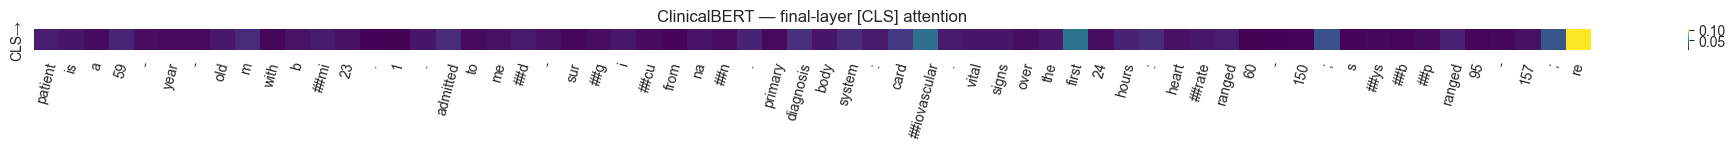

In [31]:
# Attention heatmap from the final layer — what clinical terms did the model focus on?
sample_text = notes_test_df['note'].iloc[0]
enc = tokenizer(sample_text, truncation=True, padding='max_length',
                max_length=MAX_LEN, return_tensors='pt')
ids = enc['input_ids'].to(DEVICE)
mask = enc['attention_mask'].to(DEVICE)
bert_full.eval()
with torch.no_grad():
    _, attentions = bert_full(ids, mask, return_attn=True)
# attentions = tuple of (batch, heads, seq, seq) for each layer
last = attentions[-1][0]                              # (heads, seq, seq)
avg_attn = last.mean(0)                               # average across heads → (seq, seq)
cls_attn = avg_attn[0].cpu().numpy()                  # how [CLS] attends to all tokens

tokens = tokenizer.convert_ids_to_tokens(ids[0].cpu().numpy())
real_len = int(mask.sum().item())
toks_real = tokens[:real_len]
attn_real = cls_attn[:real_len]

# Drop special tokens for cleaner display
keep = [(t, a) for t, a in zip(toks_real, attn_real)
        if t not in ('[CLS]', '[SEP]', '[PAD]')]
ks_tok, ks_a = zip(*keep)
order = np.argsort(ks_a)[::-1][:15]
print('Top-15 tokens by [CLS] attention (final layer, head-averaged):')
for i in order:
    print(f'  {ks_tok[i]:<20s}  {ks_a[i]:.4f}')

plt.figure(figsize=(min(20, 0.35 * len(ks_tok)), 1.6))
sns.heatmap(np.array(ks_a).reshape(1,-1), cmap='viridis',
            xticklabels=ks_tok, yticklabels=['CLS→'], cbar=True)
plt.xticks(rotation=75); plt.title('ClinicalBERT — final-layer [CLS] attention')
plt.tight_layout(); plt.show()


## 6. Unified Model Comparison

We collect all six models into a single table and plot confusion matrices
side-by-side. Recall is the metric to scrutinize.


In [32]:
rows = []
rows.append(('DNN (Baseline)',          dnn_res,    dnn_train_time))
rows.append(('LSTM',                    res_lstm,   hist_lstm['train_time']))
rows.append(('Bi-LSTM',                 res_bilstm, hist_bilstm['train_time']))
rows.append(('GRU',                     res_gru,    hist_gru['train_time']))
rows.append(('ClinicalBERT (Frozen)',   res_frozen, hist_frozen['train_time']))
rows.append(('ClinicalBERT (Full FT)',  res_full,   hist_full['train_time']))

table = pd.DataFrame([{
    'Model':     name,
    'Accuracy':  round(r['accuracy'], 4),
    'Precision': round(r['precision'], 4),
    'Recall':    round(r['recall'], 4),
    'F1-Score':  round(r['f1'], 4),
    'Train Time (s)': round(t, 1),
} for name, r, t in rows])
print(table.to_string(index=False))
table.to_csv('results_table.csv', index=False)
table


                 Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)
        DNN (Baseline)    0.7805     0.2584  0.8256    0.3936            25.8
                  LSTM    0.8089     0.2807  0.7776    0.4125            29.5
               Bi-LSTM    0.7971     0.2705  0.7960    0.4038            37.8
                   GRU    0.7991     0.2732  0.7997    0.4073            35.7
 ClinicalBERT (Frozen)    0.3300     0.3300  1.0000    0.4962            76.3
ClinicalBERT (Full FT)    0.3300     0.3300  1.0000    0.4962           333.3


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,DNN (Baseline),0.7805,0.2584,0.8256,0.3936,25.8
1,LSTM,0.8089,0.2807,0.7776,0.4125,29.5
2,Bi-LSTM,0.7971,0.2705,0.7960,0.4038,37.8
3,GRU,0.7991,0.2732,0.7997,0.4073,35.7
4,ClinicalBERT (Frozen),0.3300,0.3300,1.0000,0.4962,76.3
5,ClinicalBERT (Full FT),0.3300,0.3300,1.0000,0.4962,333.3


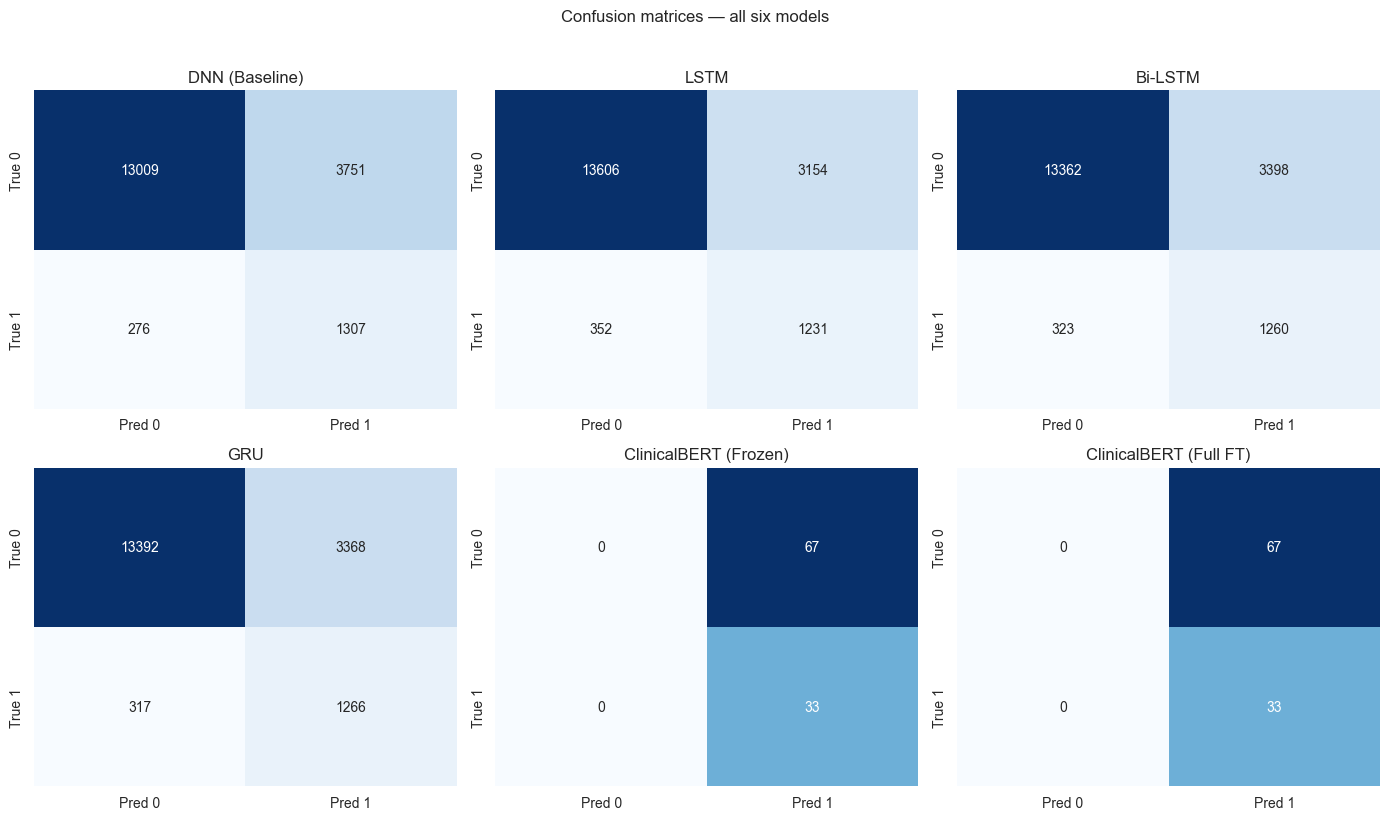

In [33]:
# Confusion matrices side by side
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (name, r, _) in zip(axes.flat, rows):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'], cbar=False)
    ax.set_title(name)
plt.suptitle('Confusion matrices — all six models', y=1.02)
plt.tight_layout(); plt.show()


**Final note.** The unified table is the headline artifact of Part A.
For a clinical deployment we would compare on the **Recall** column first
(missed deterioration is the most expensive error), then look at Precision
to gauge alarm-fatigue cost, and finally use F1 as a single-number summary.
